#Задание 3 #

**Часть 1 доделываем семинар и получаем SNP**

Для сравнения геномов E. coli K-12 и E. coli O157:H7 было выполнено полногеномное выравнивание с помощью nucmer, затем выравнивание было отфильтровано командой delta-filter -1 -i 90, после чего различия были извлечены утилитой show-snps.

Всего в файле различий было обнаружено 73161 варианта.
После исключения indel-событий осталось 68920 однонуклеотидных замен (SNP).

Таким образом шапка таблицы имеет такой вид:
P1  REF  ALT  P2  BUFF  DIST  LEN_R  LEN_Q  FRM_R  FRM_Q  REF_CONTIG  QRY_CONTIG
 где
P1 — позиция SNP в референсном геноме (E. coli K-12)
REF — нуклеотид в референсном геноме
ALT — альтернативный нуклеотид в сравниваемом геноме (E. coli O157:H7)
P2 — соответствующая позиция в геноме запроса
BUFF — расстояние до ближайшего другого различия в том же блоке выравнивания
DIST — расстояние до ближайшей границы блока выравнивания
LEN_R — длина референсной последовательности
LEN_Q — длина последовательности запроса
FRM_R — ориентация референсной последовательности в выравнивании
FRM_Q — ориентация последовательности запроса в выравнивании
REF_CONTIG — идентификатор референсной последовательности
QRY_CONTIG — идентификатор последовательности запроса.

Исходный файл show-snps содержал не только SNP, но и indel-события. Для дальнейшей аннотации был сформирован отдельный файл ecoli_snps_only.tsv, содержащий только однонуклеотидные замены:

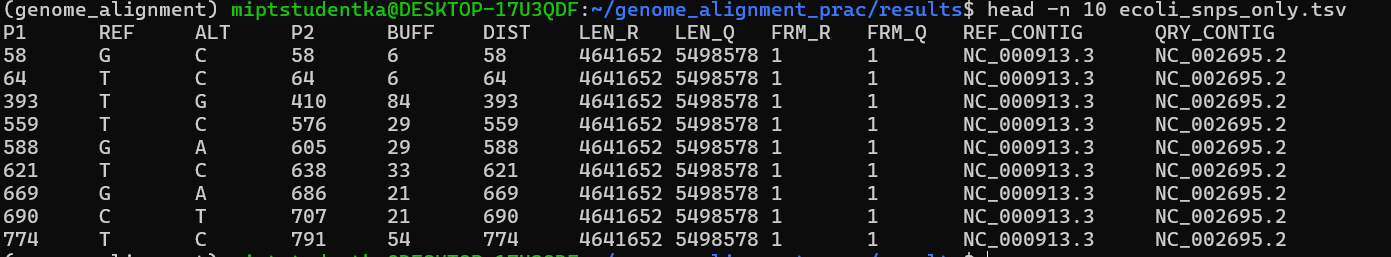

**Часть 2 Аннотация SNP**

Для аннотации SNP был использован файл ecoli_snps_only.tsv, содержащий только однонуклеотидные замены, и файл GenBank ecoli_k12.gbff с аннотацией референсного генома E. coli K-12.
Для каждого SNP определялись:

-положение относительно аннотированных генов
-принадлежность к CDS или межгенному участку
-тип замены (synonymous / nonsynonymous, если SNP находился в CDS)
-минокислотная замена
-потенциальное функциональное значение.

Аннотация выполнялась Python-скриптом с использованием библиотек pandas и Biopython.
Скрипт загружал SNP-файл, считывал GenBank-аннотацию, сопоставлял координаты SNP с координатами генов и CDS, а для SNP в кодирующих областях определял изменение кодона и аминокислотную замену.

### Python-скрипт аннотации SNP

Ниже приведён Python-скрипт `annotate_snps.py`, который использовался для аннотации SNP.

In [ ]:
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq

SNP_FILE = "../results/ecoli_snps_only.tsv"
GBFF_FILE = "../data/ecoli_k12.gbff"
OUT_FILE = "../results/annotated_snps.tsv"

# Загружаем SNP
snps = pd.read_csv(SNP_FILE, sep="\t")

# Загружаем GenBank
record = SeqIO.read(GBFF_FILE, "genbank")
genome_seq = record.seq

# Собираем CDS и gene
genes = []
cds_features = []

for feature in record.features:
    if feature.type == "gene":
        genes.append(feature)
    elif feature.type == "CDS":
        cds_features.append(feature)

def get_qual(feature, key, default="NA"):
    return feature.qualifiers.get(key, [default])[0]

def find_gene_features(pos1):
    hits = []
    for feature in genes:
        start = int(feature.location.start) + 1
        end = int(feature.location.end)
        if start <= pos1 <= end:
            hits.append(feature)
    return hits

def find_cds_features(pos1):
    hits = []
    for feature in cds_features:
        start = int(feature.location.start) + 1
        end = int(feature.location.end)
        if start <= pos1 <= end:
            hits.append(feature)
    return hits

def annotate_cds_snp(feature, pos1, ref_base, alt_base):
    strand = feature.location.strand
    cds_seq = feature.extract(genome_seq)

    start0 = int(feature.location.start)
    end0 = int(feature.location.end)

    if strand == 1:
        offset = pos1 - (start0 + 1)
        alt_for_codon = alt_base
    else:
        offset = end0 - pos1
        alt_for_codon = str(Seq(alt_base).reverse_complement())

    if offset < 0 or offset >= len(cds_seq):
        return {
            "effect": "NA",
            "codon_ref": "NA",
            "codon_alt": "NA",
            "aa_ref": "NA",
            "aa_alt": "NA",
            "aa_change": "NA"
        }

    codon_start = (offset // 3) * 3
    codon_pos = offset % 3

    if codon_start + 3 > len(cds_seq):
        return {
            "effect": "NA",
            "codon_ref": "NA",
            "codon_alt": "NA",
            "aa_ref": "NA",
            "aa_alt": "NA",
            "aa_change": "NA"
        }

    codon_ref = str(cds_seq[codon_start:codon_start + 3]).upper()
    codon_alt_list = list(codon_ref)
    codon_alt_list[codon_pos] = alt_for_codon.upper()
    codon_alt = "".join(codon_alt_list)

    aa_ref = str(Seq(codon_ref).translate())
    aa_alt = str(Seq(codon_alt).translate())

    aa_number = codon_start // 3 + 1

    if aa_ref == aa_alt:
        effect = "synonymous"
    else:
        effect = "nonsynonymous"

    aa_change = f"p.{aa_ref}{aa_number}{aa_alt}"

    return {
        "effect": effect,
        "codon_ref": codon_ref,
        "codon_alt": codon_alt,
        "aa_ref": aa_ref,
        "aa_alt": aa_alt,
        "aa_change": aa_change
    }

def functional_note(effect, product, region_type):
    product_l = str(product).lower()

    if region_type == "intergenic":
        return "possible regulatory/intergenic effect"
    if effect == "synonymous":
        return "likely low direct effect on protein sequence"
    if effect == "nonsynonymous":
        if any(k in product_l for k in ["transporter", "pump", "porin", "membrane"]):
            return "may affect transport/membrane-associated function"
        if any(k in product_l for k in ["regulator", "repressor", "activator"]):
            return "may affect regulatory function"
        if any(k in product_l for k in ["enzyme", "synthetase", "dehydrogenase", "kinase"]):
            return "may affect enzymatic activity"
        return "may affect protein function"
    return "NA"

rows = []

for _, row in snps.iterrows():
    pos1 = int(row["P1"])
    ref_base = str(row["REF"]).upper()
    alt_base = str(row["ALT"]).upper()

    gene_hits = find_gene_features(pos1)
    cds_hits = find_cds_features(pos1)

    if cds_hits:
        cds = cds_hits[0]
        gene_name = get_qual(cds, "gene", "NA")
        locus_tag = get_qual(cds, "locus_tag", "NA")
        product = get_qual(cds, "product", "NA")
        strand = cds.location.strand
        region_type = "CDS"

        ann = annotate_cds_snp(cds, pos1, ref_base, alt_base)
        effect = ann["effect"]
        codon_ref = ann["codon_ref"]
        codon_alt = ann["codon_alt"]
        aa_ref = ann["aa_ref"]
        aa_alt = ann["aa_alt"]
        aa_change = ann["aa_change"]

    elif gene_hits:
        gene = gene_hits[0]
        gene_name = get_qual(gene, "gene", "NA")
        locus_tag = get_qual(gene, "locus_tag", "NA")
        product = "non-CDS gene feature"
        strand = gene.location.strand
        region_type = "gene_non_coding"

        effect = "non_coding_gene"
        codon_ref = "NA"
        codon_alt = "NA"
        aa_ref = "NA"
        aa_alt = "NA"
        aa_change = "NA"

    else:
        gene_name = "intergenic"
        locus_tag = "NA"
        product = "NA"
        strand = "NA"
        region_type = "intergenic"

        effect = "intergenic"
        codon_ref = "NA"
        codon_alt = "NA"
        aa_ref = "NA"
        aa_alt = "NA"
        aa_change = "NA"

    note = functional_note(effect, product, region_type)

    out = dict(row)
    out["region_type"] = region_type
    out["gene"] = gene_name
    out["locus_tag"] = locus_tag
    out["product"] = product
    out["strand"] = strand
    out["effect"] = effect
    out["codon_ref"] = codon_ref
    out["codon_alt"] = codon_alt
    out["aa_ref"] = aa_ref
    out["aa_alt"] = aa_alt
    out["aa_change"] = aa_change
    out["functional_note"] = note

    rows.append(out)

annotated = pd.DataFrame(rows)
annotated.to_csv(OUT_FILE, sep="\t", index=False)

print("Saved:", OUT_FILE)
print("Total annotated SNPs:", len(annotated))
print(annotated["effect"].value_counts(dropna=False))

### Результаты аннотации SNP

После аннотации был получен файл `annotated_snps.tsv`, содержащий информацию о положении SNP относительно генов, типе эффекта, замене кодона и аминокислотной замене.

По результатам аннотации было выявлено 68920 SNP. Из них:
- `synonymous` — 49831
- `nonsynonymous` — 9915
- `intergenic` — 7066
- `non_coding_gene` — 1862
- `NA` — 246

Таким образом, большинство SNP в кодирующих областях являются синонимичными, однако значительное число замен относится к несинонимичным и потенциально может влиять на свойства соответствующих белков.

### Визуализация распределения SNP

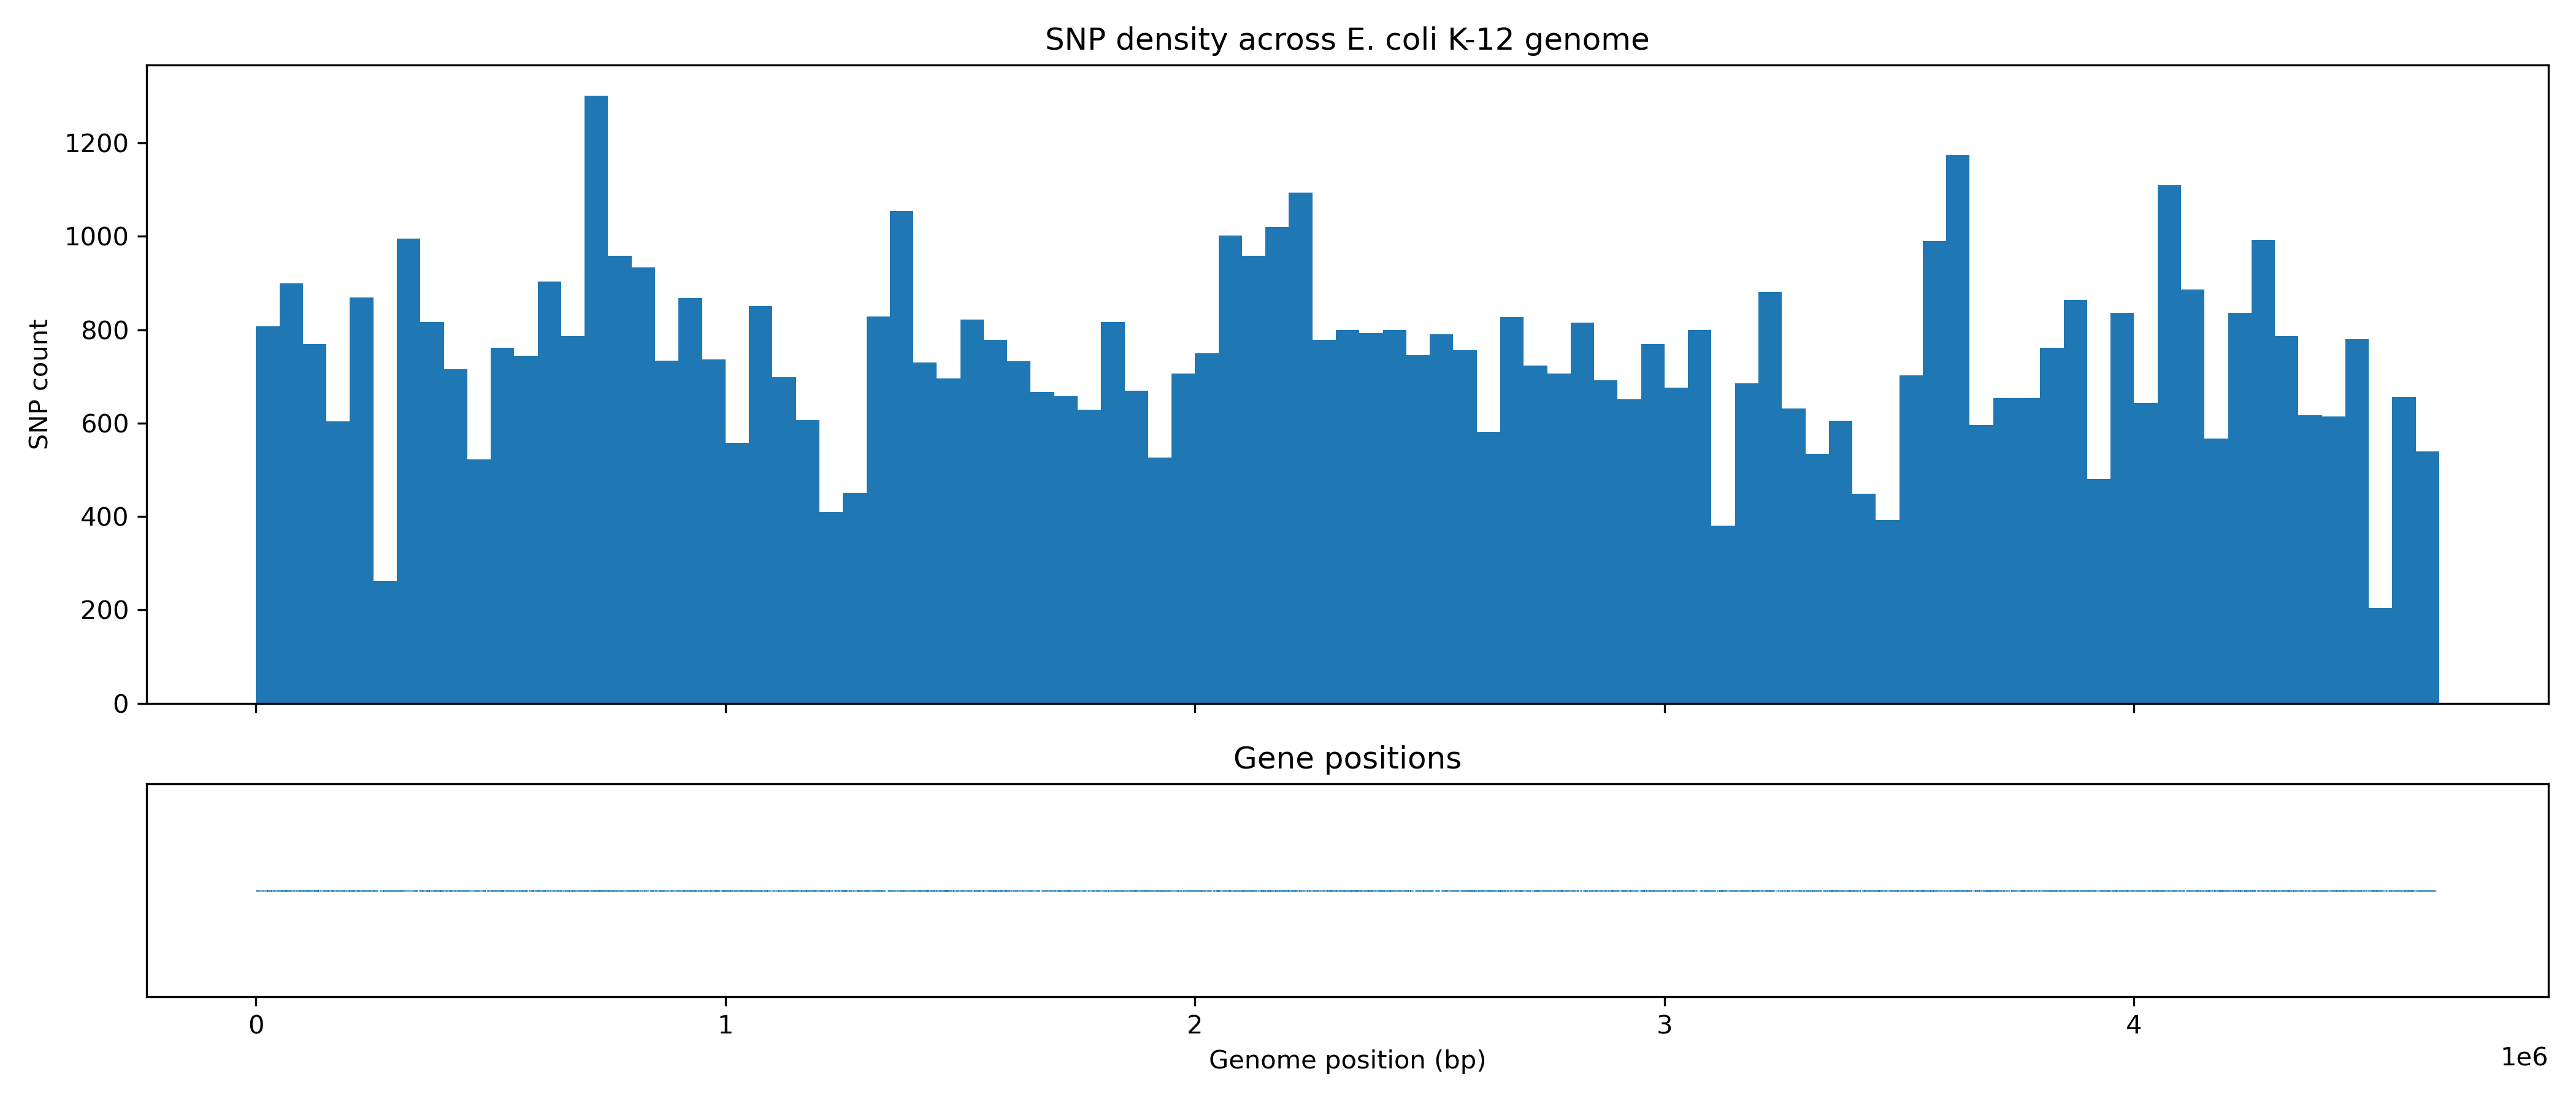

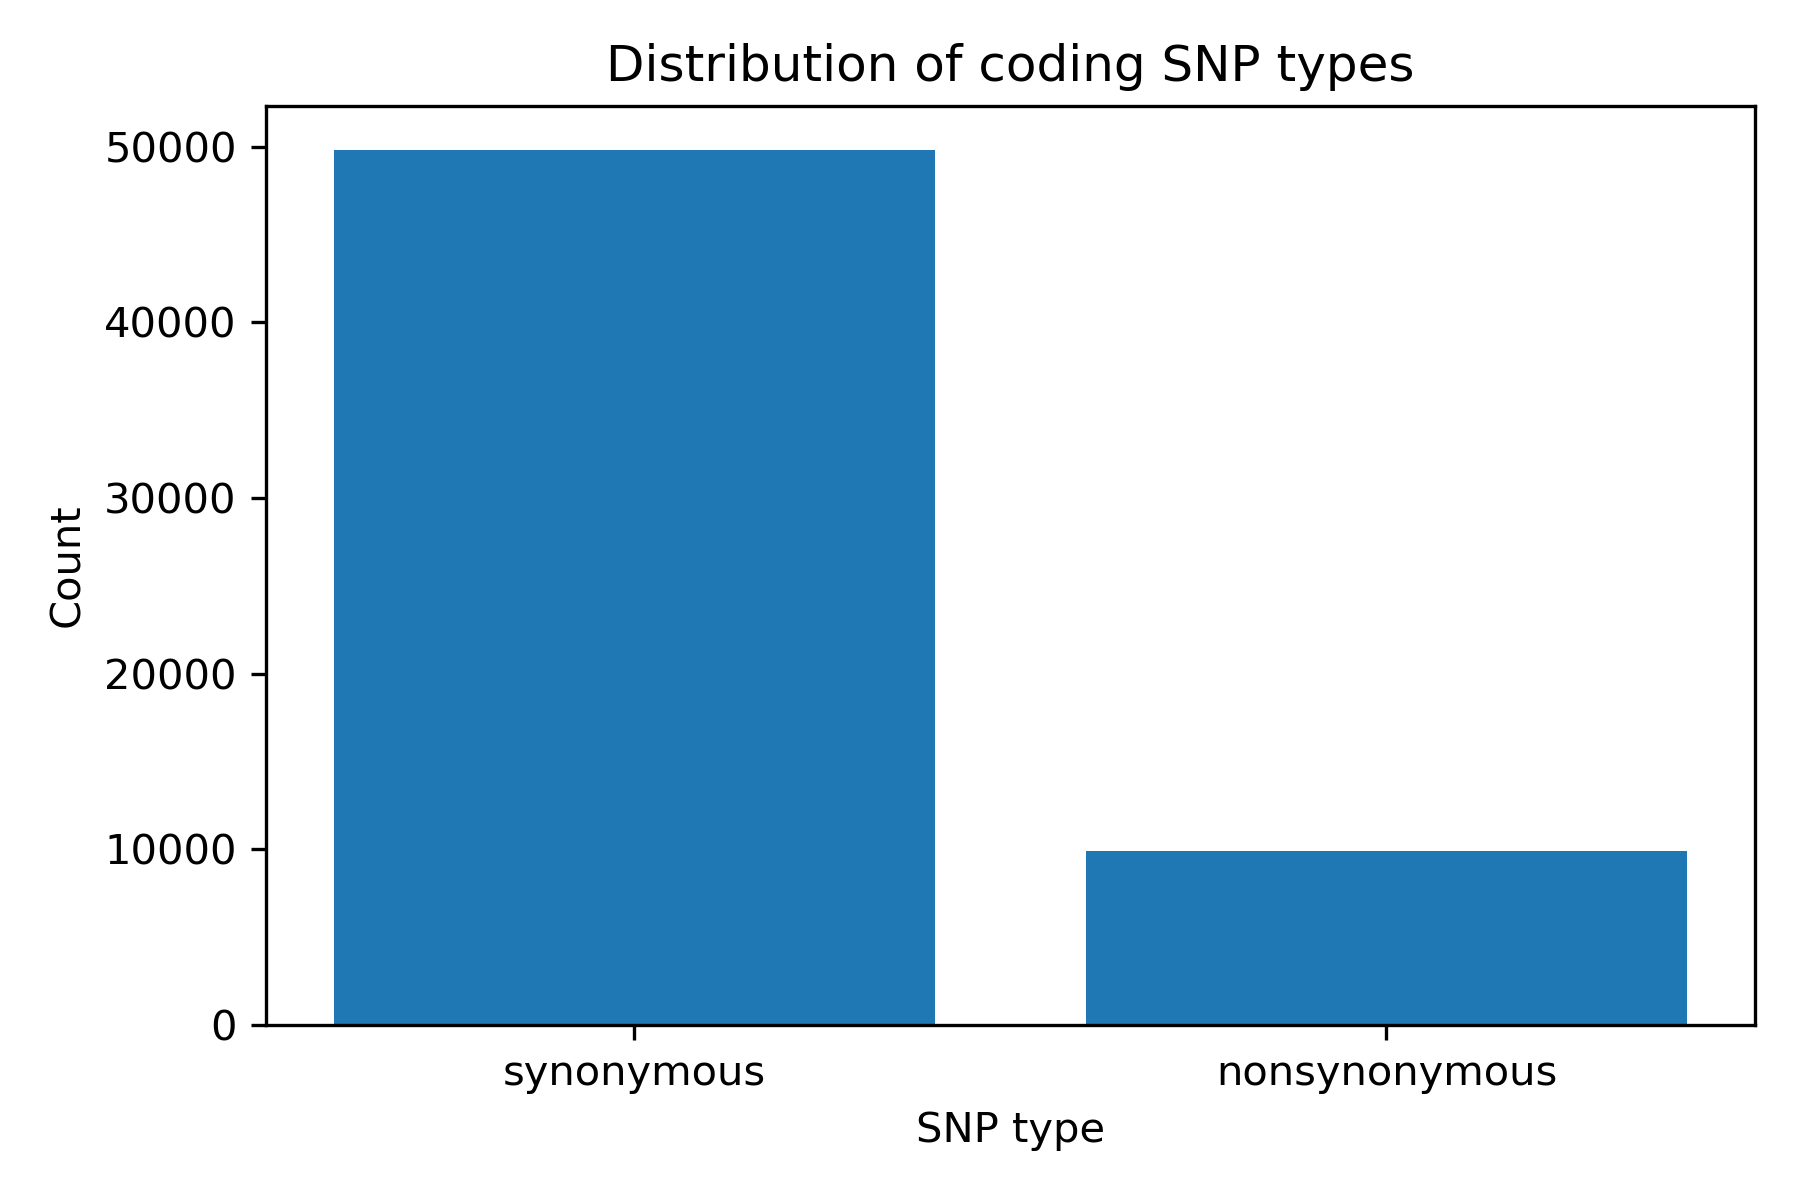

На графике плотности SNP видно, что варианты распределены по геному неравномерно: присутствуют участки с повышенной и пониженной плотностью замен. Это может отражать различия в степени консервативности отдельных участков генома и особенности дивергенции между штаммами *E. coli* K-12 и *E. coli* O157:H7.

Диаграмма распределения кодирующих SNP показывает, что число синонимичных замен значительно превышает число несинонимичных. Это ожидаемо, поскольку не каждая замена нуклеотида в CDS приводит к изменению аминокислоты. Тем не менее почти десять тысяч несинонимичных SNP представляют интерес для дальнейшего функционального анализа.

### Топ-10 генов по числу SNP

| gene | locus_tag | product                                              | snp_count |
| ---- | --------- | ---------------------------------------------------- | --------: |
| ybgQ | b0718     | putative fimbrial usher protein YbgQ                 |       430 |
| yeeJ | b1978     | inverse autotransporter adhesin                      |       250 |
| ybgO | b0716     | putative fimbrial protein YbgO                       |       218 |
| yehI | b2118     | DUF4132 domain-containing protein YehI               |       191 |
| ybgP | b0717     | putative fimbrial chaperone YbgP                     |       165 |
| ydbA | b4492     | putative outer membrane protein, N-terminal fragment |       164 |
| yfaL | b2233     | putative autotransporter adhesin YfaL                |       139 |
| yjgL | b4253     | protein YjgL                                         |       139 |
| entF | b0586     | apo-serine activating enzyme                         |       131 |
| yhiL | b4660     | non-CDS gene feature                                 |       131 |



### Вывод по пункту 2

В результате аннотации SNP удалось перейти от списка координат замен к их биологической интерпретации. Было показано, что большая часть SNP в кодирующих областях является синонимичной, однако значительное число вариантов относится к несинонимичным заменам. Анализ распределения SNP по геному показал неравномерную плотность вариативности.

Среди наиболее вариабельных генов оказались гены, связанные с фимбриями, адгезией и белками наружной мембраны, что делает их перспективными кандидатами для дальнейшего анализа функционально значимых различий между штаммами.

**Часть 3. Поиск функционально значимых SNP**

В качестве направления для поиска функционально значимых SNP я выбрала анализ несинонимичных замен в генах, связанных с поверхностными структурами бактерии и потенциальной вирулентностью. Такой выбор кажется логичным, потому что на предыдущем этапе среди наиболее вариабельных генов были обнаружены гены, связанные с фимбриями, адгезией и белками наружной мембраны. Именно такие белки могут быть важны для прикрепления бактерии к клеткам хозяина и взаимодействия с окружающей средой.

Для анализа я отобрала только несинонимичные SNP, так как именно они приводят к замене аминокислоты в белке и поэтому потенциально могут влиять на его функцию. Затем среди этих SNP были выбраны варианты в генах, аннотация которых содержала признаки связи с адгезией и поверхностными структурами, например `adhesin`, `fimbrial`, `usher`, `autotransporter`.

В результате были получены следующие гены-кандидаты с наибольшим числом несинонимичных SNP:

| gene | locus_tag | product | nonsyn_snp_count |
|---|---|---|---:|
| ybgQ | b0718 | putative fimbrial usher protein YbgQ | 118 |
| yeeJ | b1978 | inverse autotransporter adhesin | 114 |
| ybgO | b0716 | putative fimbrial protein YbgO | 61 |
| ybgP | b0717 | putative fimbrial chaperone YbgP | 59 |
| yfaL | b2233 | putative autotransporter adhesin YfaL | 57 |
| ypjA | b2647 | adhesin-like autotransporter YpjA | 37 |
| yejO | b2190 | adhesin-like autotransporter YejO | 30 |
| flu | b2000 | self recognizing antigen 43 (Ag43) autotransporter | 30 |
| djlC | b0649 | co-chaperone DjlC | 23 |
| ompL | b3875 | putative outer membrane porin L | 19 |
| yraH | b3142 | putative fimbrial protein YraH | 13 |
| ompC | b2215 | outer membrane porin C | 13 |
| elfC | b0940 | putative fimbrial usher protein ElfC | 12 |
| btuB | b3966 | cobalamin outer membrane transporter | 11 |
| ydhQ | b1664 | putative adhesin-related protein YdhQ | 11 |

Наиболее интересными мне кажутся гены `ybgQ`, `yeeJ`, `ybgO`, `ybgP` и `yfaL`, потому что они прямо связаны с фимбриями или белками адгезии. Например, `yeeJ` и `yfaL` аннотированы как adhesin/autotransporter adhesin-подобные белки, а `ybgQ`, `ybgO` и `ybgP` относятся к фимбриальным структурам. Также обращают на себя внимание `ypjA`, `yejO` и `flu`, так как они тоже связаны с adhesin-like или autotransporter-белками.

Конечно, по одному только биоинформатическому анализу нельзя утверждать, что найденные замены точно определяют вирулентность. Но такие SNP можно рассматривать как кандидатные функционально значимые варианты, потому что они находятся в генах, связанных с поверхностными белками, и меняют аминокислотную последовательность. Таким образом результаты данного анализа можно использовать для определения того какие именно гены и какие именно замены отличают безопасный лабораторный штамм от патогенного. Также результаты помогают понять механизмы патогенности, это применимо в разработке лекарств, вакцин и антибактериальных стратегий.



Была использована статья Kulasekara et al., в которой для штамма E. coli O157:H7 обсуждаются кандидатные детерминанты повышенной вирулентности, включая norV и несколько других генетических признаков. В моём анализе прямых совпадений с такими кандидатами найдено не было. Вместо этого среди генов с наибольшим числом несинонимичных SNP оказались гены, связанные с адгезией, фимбриями и поверхностными белками (ybgQ, yeeJ, ybgO, ybgP, yfaL и др.). Таким образом, мои результаты не повторяют данные статьи напрямую, но тоже указывают на набор генов-кандидатов, которые потенциально могут быть связаны с биологически значимыми различиями между штаммами.

### Вывод по пункту 3

В результате анализа были выделены несинонимичные SNP в генах, связанных с поверхностными структурами бактерии и потенциальной вирулентностью. Наиболее интересные кандидаты были найдены в генах `ybgQ`, `yeeJ`, `ybgO`, `ybgP`, `yfaL`, `ypjA`, `yejO` и `flu`. Поскольку продукты этих генов участвуют в адгезии, работе фимбрий и autotransporter-систем, найденные замены могут быть связаны с функциональными различиями между *E. coli* K-12 и *E. coli* O157:H7.